✅ Library berhasil diimport
Total gigs: 1259

Distribusi Kategori:
category
Other Data Services            498
Data Engineering & Big Data    280
Machine Learning & AI          184
Web Scraping & Data Mining     162
Excel & Google Sheets          135
Name: count, dtype: int64

RINGKASAN MARKET GAP
                             jumlah_gig  rata_rata_reviewer  median_reviewer  \
category                                                                       
Excel & Google Sheets               135               154.2             22.0   
Web Scraping & Data Mining          162               110.8             10.5   
Machine Learning & AI               184                23.7             14.0   
Other Data Services                 498                10.5              0.0   
Data Engineering & Big Data         280                 2.2              0.0   

                             rata_rata_harga  gig_dengan_0_reviewer  \
category                                                             

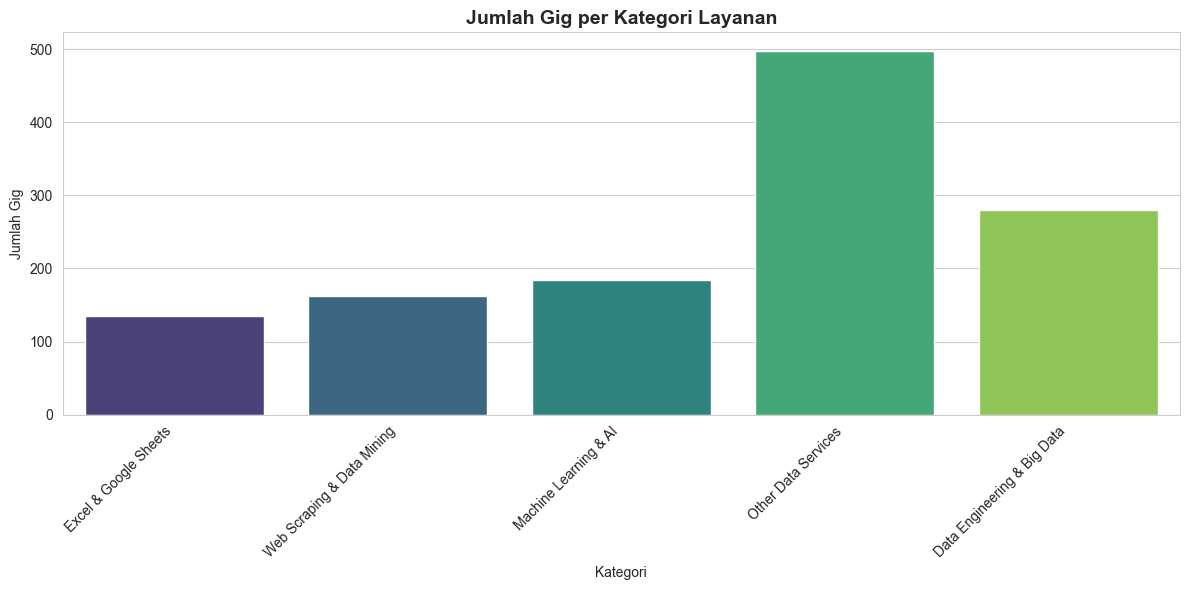

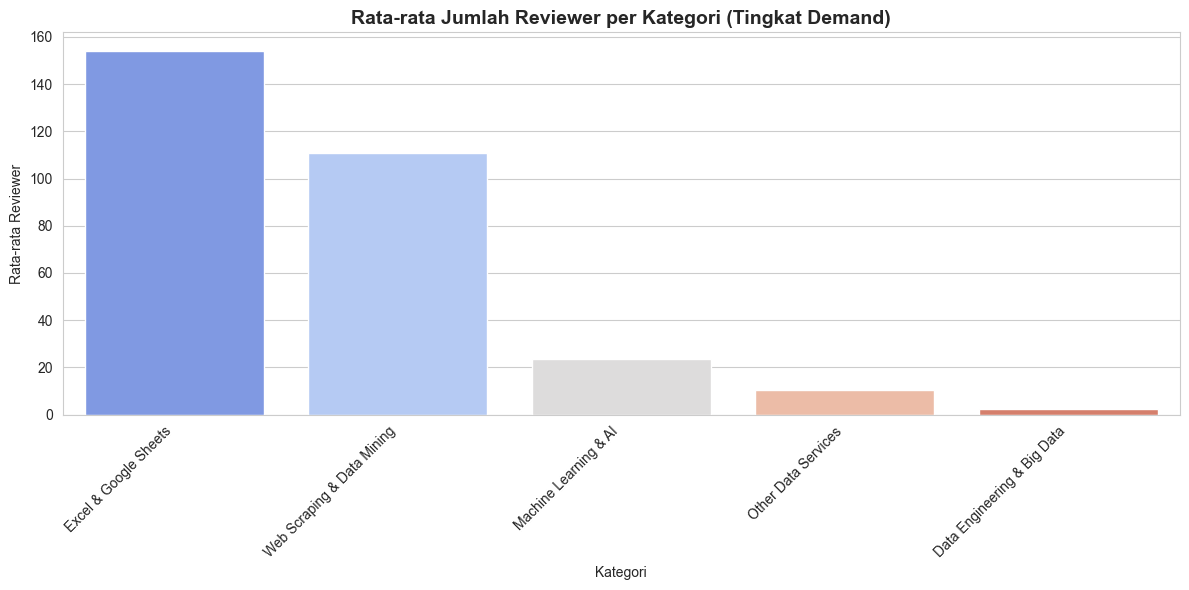

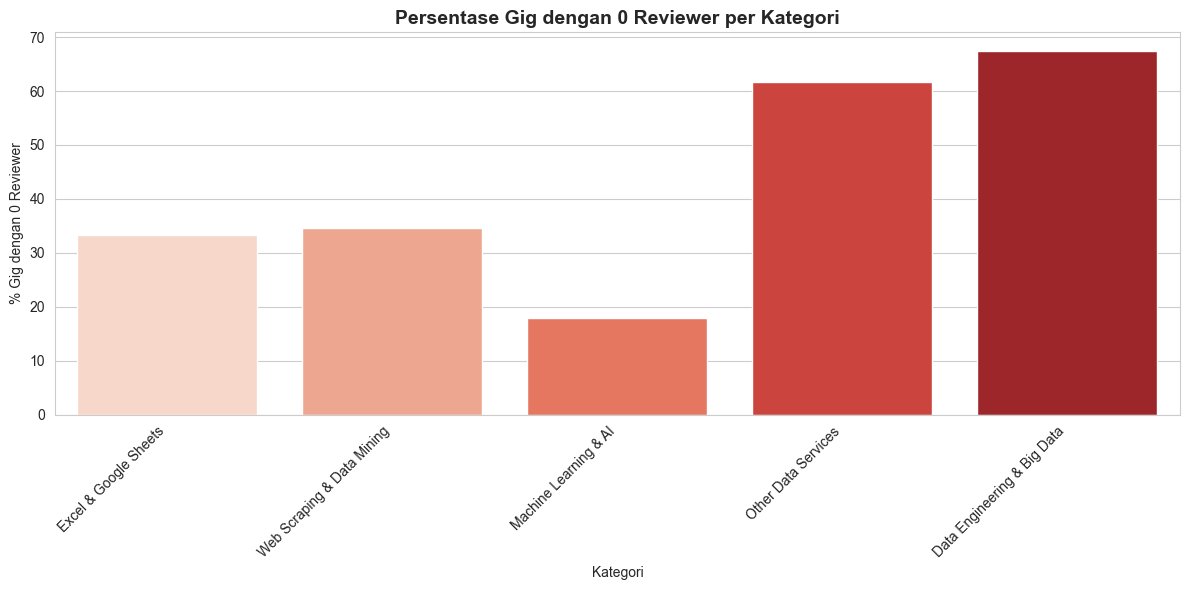

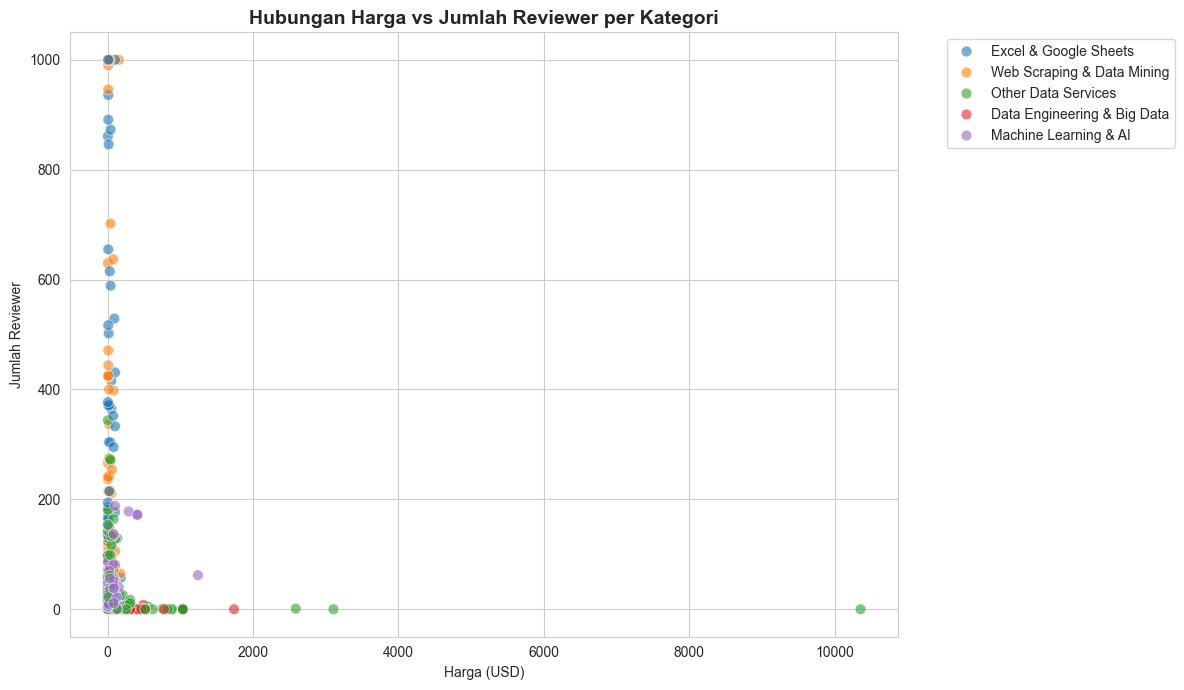


🔍 ANALISIS MARKET GAP

KESIMPULAN UTAMA:

1. WEB SCRAPING & DATA MINING
   - Jumlah gig: Tinggi
   - Rata-rata reviewer: TERTINGGI → HIGH DEMAND
   - Persentase 0 reviewer: Rendah
   → Kategori ini paling ramai dan paling banyak dicari buyer

2. EXCEL & GOOGLE SHEETS
   - Jumlah gig: Sangat tinggi
   - Rata-rata reviewer: Tinggi
   → Masih sangat diminati, kompetisi ketat

3. MACHINE LEARNING & AI
   - Jumlah gig: Cukup banyak (supply tinggi)
   - Rata-rata reviewer: SANGAT RENDAH
   - Persentase 0 reviewer: Tinggi
   → OVERSUPPLY! Banyak seller tapi sedikit buyer

4. DATA ENGINEERING & BIG DATA
   - Jumlah gig: Sedang
   - Rata-rata reviewer: Rendah
   - Harga rata-rata: Cukup tinggi
   → Supply lebih besar dari demand saat ini

REKOMENDASI:
- Seller baru sebaiknya fokus ke Web Scraping + Excel (masih banyak permintaan)
- Seller ML/AI/Data Engineering perlu lebih agresif dalam marketing atau spesialisasi niche
- Ada peluang besar di "Machine Learning for non-technical users" atau "ML

In [1]:
# =============================================
# MARKET GAP ANALYSIS - FIVERR DATA GIGS
# =============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Library berhasil diimport")

# ================== 1. LOAD & CLEAN DATA ==================
df = pd.read_csv('fiverr-data-gigs-cleaned.csv')

# Parse Number of Reviewers
def parse_reviewers(val):
    if pd.isna(val):
        return 0
    val = str(val).lower().replace(',', '').strip()
    if 'k+' in val:
        return int(float(val.replace('k+', '')) * 1000)
    elif 'k' in val:
        return int(float(val.replace('k', '')) * 1000)
    try:
        return int(float(val))
    except:
        return 0

df['reviewers_num'] = df['Number of Reviewers'].apply(parse_reviewers)
df['price'] = df['Price (USD)']

print(f"Total gigs: {len(df)}")

# ================== 2. KATEGORISASI GIG ==================
def categorize_gig(title):
    title = str(title).lower()
    
    scraping_kw = ['web scraping', 'scrape', 'data mining', 'data extraction', 'crawling', 'scraping']
    excel_kw = ['excel', 'vba', 'google sheets', 'google sheet', 'macro', 'spreadsheet']
    ml_kw = ['machine learning', 'deep learning', 'computer vision', 'ml ', 'artificial intelligence', 
             'neural network', 'tensorflow', 'pytorch', 'yolo', 'cnn']
    de_kw = ['data engineering', 'etl', 'pipeline', 'big data', 'spark', 'aws', 'azure', 'gcp', 
             'snowflake', 'databricks', 'airflow', 'data warehouse']
    
    if any(kw in title for kw in scraping_kw):
        return 'Web Scraping & Data Mining'
    elif any(kw in title for kw in excel_kw):
        return 'Excel & Google Sheets'
    elif any(kw in title for kw in ml_kw):
        return 'Machine Learning & AI'
    elif any(kw in title for kw in de_kw):
        return 'Data Engineering & Big Data'
    else:
        return 'Other Data Services'

df['category'] = df['Title'].apply(categorize_gig)

print("\nDistribusi Kategori:")
print(df['category'].value_counts())

# ================== 3. RINGKASAN MARKET GAP ==================
summary = df.groupby('category').agg(
    jumlah_gig=('Title', 'count'),
    rata_rata_reviewer=('reviewers_num', 'mean'),
    median_reviewer=('reviewers_num', 'median'),
    rata_rata_harga=('price', 'mean'),
    gig_dengan_0_reviewer=('reviewers_num', lambda x: (x == 0).sum())
).round(1)

summary['persen_0_reviewer'] = (summary['gig_dengan_0_reviewer'] / summary['jumlah_gig'] * 100).round(1)
summary = summary.sort_values('rata_rata_reviewer', ascending=False)

print("\n" + "="*70)
print("RINGKASAN MARKET GAP")
print("="*70)
print(summary)

# ================== 4. VISUALISASI ==================

# Plot 1: Jumlah Gig per Kategori
plt.figure(figsize=(12,6))
sns.barplot(data=summary.reset_index(), x='category', y='jumlah_gig', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Jumlah Gig per Kategori Layanan', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Gig')
plt.xlabel('Kategori')
plt.tight_layout()
plt.show()

# Plot 2: Rata-rata Reviewer per Kategori (Demand)
plt.figure(figsize=(12,6))
sns.barplot(data=summary.reset_index(), x='category', y='rata_rata_reviewer', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Rata-rata Jumlah Reviewer per Kategori (Tingkat Demand)', fontsize=14, fontweight='bold')
plt.ylabel('Rata-rata Reviewer')
plt.xlabel('Kategori')
plt.tight_layout()
plt.show()

# Plot 3: Persentase Gig dengan 0 Reviewer
plt.figure(figsize=(12,6))
sns.barplot(data=summary.reset_index(), x='category', y='persen_0_reviewer', palette='Reds')
plt.xticks(rotation=45, ha='right')
plt.title('Persentase Gig dengan 0 Reviewer per Kategori', fontsize=14, fontweight='bold')
plt.ylabel('% Gig dengan 0 Reviewer')
plt.xlabel('Kategori')
plt.tight_layout()
plt.show()

# Plot 4: Scatter Plot Harga vs Reviewer
plt.figure(figsize=(12,7))
sns.scatterplot(data=df, x='price', y='reviewers_num', hue='category', alpha=0.6, s=60)
plt.title('Hubungan Harga vs Jumlah Reviewer per Kategori', fontsize=14, fontweight='bold')
plt.xlabel('Harga (USD)')
plt.ylabel('Jumlah Reviewer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ================== 5. KESIMPULAN MARKET GAP ==================
print("\n" + "="*70)
print("🔍 ANALISIS MARKET GAP")
print("="*70)

print("""
KESIMPULAN UTAMA:

1. WEB SCRAPING & DATA MINING
   - Jumlah gig: Tinggi
   - Rata-rata reviewer: TERTINGGI → HIGH DEMAND
   - Persentase 0 reviewer: Rendah
   → Kategori ini paling ramai dan paling banyak dicari buyer

2. EXCEL & GOOGLE SHEETS
   - Jumlah gig: Sangat tinggi
   - Rata-rata reviewer: Tinggi
   → Masih sangat diminati, kompetisi ketat

3. MACHINE LEARNING & AI
   - Jumlah gig: Cukup banyak (supply tinggi)
   - Rata-rata reviewer: SANGAT RENDAH
   - Persentase 0 reviewer: Tinggi
   → OVERSUPPLY! Banyak seller tapi sedikit buyer

4. DATA ENGINEERING & BIG DATA
   - Jumlah gig: Sedang
   - Rata-rata reviewer: Rendah
   - Harga rata-rata: Cukup tinggi
   → Supply lebih besar dari demand saat ini

REKOMENDASI:
- Seller baru sebaiknya fokus ke Web Scraping + Excel (masih banyak permintaan)
- Seller ML/AI/Data Engineering perlu lebih agresif dalam marketing atau spesialisasi niche
- Ada peluang besar di "Machine Learning for non-technical users" atau "ML untuk bisnis kecil"
""")